## check hsg gene expression in the data- NEW

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packag

In [2]:
#upload hsg
hsg=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/updated_human_specific_genes3.csv")
new_hsg=

In [3]:
#upload har
har_genes=pd.read_excel("/scratch200/reutj/data/hsg_gene_lists/har_associated_genes.xlsx",header=1)

In [4]:
#upload data
adata=sc.read_h5ad("/scratch200/reutj/data/updated_cortex_data_hg38.h5ad")

In [21]:
adata

AnnData object with n_obs × n_vars = 297927 × 33538
    obs: 'Age', 'Agetext', 'Ageunit', 'All_fc_analysis_id', 'Analysis', 'CellCycle', 'CellCycle_G1', 'CellCycle_G2M', 'CellCycle_S', 'Cellconc', 'Chemistry', 'Clusters', 'ClustersModularity', 'ClustersSurprise', 'Cmobarcodes', 'Comment', 'CreationDate', 'Datecaptured', 'Donor', 'DoubletFinderFlag', 'DoubletFinderScore', 'Editat', 'Editby', 'Id', 'IsCycling', 'Label', 'MT_ratio', 'MeanTotalUMI', 'Method', 'NGenes', 'Name', 'Neuronprop', 'Numpooledanimals', 'Outliers', 'OutliersModularity', 'OutliersSurprise', 'PassedQC', 'PassedQC_MT_ratio', 'PassedQC_TotalUMI', 'PassedQC_UMIPerGene', 'PassedQC_UnsplicedRatio', 'Plugdate', 'Project', 'Roi', 'SampleID', 'Sampleok', 'Sex', 'Shortname', 'Species', 'Strain', 'Subset', 'Targetnumcells', 'Tissue', 'TotalRNA', 'TotalUMI', 'Transcriptome', '_X', '_Y', 'passedQC', 'unspliced_ratio', 'velocyto.__version__', 'velocyto.logic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'louvain', 'clas

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
genes_adata=adata.var_names.tolist()

In [7]:
ens_adata=adata.var["Accession"].to_list()

In [8]:
### results dictionary for ensg
results_ens = {"gene": [], "num_cells_expressed": [], "mean_expression": []}

# Loop through each gene in the list
hsens=list(hsg["ens"])
for gene in hsens:
    if gene in ens_adata:
        print(gene)
        ind= ens_adata.index(gene)
        print(ind)
        # Get expression data for the gene from counts layer
        gene_counts = adata.X[:,ind].toarray().flatten()
        
        # Count cells with expression > 0
        num_cells_expressed = np.sum(gene_counts > 0)
        
        # Calculate mean expression for cells with expression > 0
        mean_expression = gene_counts[gene_counts > 0].mean() if num_cells_expressed > 0 else 0
        
        # Store results
        results_ens["gene"].append(gene)
        results_ens["num_cells_expressed"].append(num_cells_expressed)
        results_ens["mean_expression"].append(mean_expression)
    else:
        print(f"{gene} is not in adata")

ENSG00000122545
18000
ENSG00000215458
26438
ENSG00000135776
18226
ENSG00000140798
13887
ENSG00000091262
18839
ENSG00000119688
20197
ENSG00000129968
17599
ENSG00000204380
25456
ENSG00000145063
23874
ENSG00000204581
27676
ENSG00000133627
12460
ENSG00000197381
3334
ENSG00000178803
30246
ENSG00000144218
24517
ENSG00000173467
29745
ENSG00000135541
1378
ENSG00000063438
30022
ENSG00000205424
13884
ENSG00000012779
6084
ENSG00000237763
11609
ENSG00000174876
2831
ENSG00000243480
2440
ENSG00000240038
11849
ENSG00000153107
24892
ENSG00000183148
2959
ENSG00000172014
15870
ENSG00000148513
12345
ENSG00000264230 is not in adata
ENSG00000164062
21687
ENSG00000100342
10433
ENSG00000062725
19692
ENSG00000165269
26024
ENSG00000169083
23558
ENSG00000109321
26074
ENSG00000187951 is not in adata
ENSG00000075884
18515
ENSG00000165895
9330
ENSG00000066279
19656
ENSG00000166377
23328
ENSG00000076108
18510
ENSG00000107779
20818
ENSG00000183336
13773
ENSG00000152430
25494
ENSG00000204290
27531
ENSG00000173715
229

In [9]:
hsg_exp = pd.DataFrame(results_ens)
hsg_exp

,gene,num_cells_expressed,mean_expression
0,ENSG00000122545,263655,3.986133
1,ENSG00000215458,302,1.019868
2,ENSG00000135776,34502,1.295606
3,ENSG00000140798,296,1.074324
4,ENSG00000091262,1554,1.072716
...,...,...,...
486,ENSG00000112679,20241,1.148609
487,ENSG00000263001,169611,2.369233
488,ENSG00000198826,40577,2.102004
489,ENSG00000158517,273,1.014652


In [10]:
hsg_exp=hsg_exp.rename(columns={"gene":"ens"})
hsg_exp=pd.merge(hsg,hsg_exp,on="ens").iloc[:,1:]

In [11]:
hsg_exp.loc[hsg_exp["num_cells_expressed"]>100,:]

,gene,ens,Annotated as,num_cells_expressed,mean_expression
0,SEPTIN7,ENSG00000122545,protein_coding,263655,3.986133
1,AATBC,ENSG00000215458,antisense,302,1.019868
2,ABCB10,ENSG00000135776,protein_coding,34502,1.295606
3,ABCC12,ENSG00000140798,protein_coding,296,1.074324
4,ABCC6,ENSG00000091262,protein_coding,1554,1.072716
...,...,...,...,...,...
494,GTF2I,ENSG00000263001,protein_coding,169611,2.369233
495,ARHGAP11A,ENSG00000198826,protein_coding,40577,2.102004
496,NCF1,ENSG00000158517,protein_coding,273,1.014652
497,GPRIN2,ENSG00000204175,protein_coding,2169,1.048870


In [12]:
hsg_exp.to_csv('hsg_exp_in_adata_cortex3.csv')

In [13]:
#results dictionary for ensg -har
results_ens_har = {"gene": [], "num_cells_expressed": [], "mean_expression": []}

# Loop through each gene in the list
hsens=list(har_genes["HAR-associated genes"])
for gene in hsens:
    if gene in ens_adata:
        print(gene)
        ind= ens_adata.index(gene)
        print(ind)
        # Get expression data for the gene from counts layer
        gene_counts = adata.X[:,ind].toarray().flatten()
        
        # Count cells with expression > 0
        num_cells_expressed = np.sum(gene_counts > 0)
        
        # Calculate mean expression for cells with expression > 0
        mean_expression = gene_counts[gene_counts > 0].mean() if num_cells_expressed > 0 else 0
        
        # Store results
        results_ens_har["gene"].append(gene)
        results_ens_har["num_cells_expressed"].append(num_cells_expressed)
        results_ens_har["mean_expression"].append(mean_expression)
    else:
        print(f"{gene} is not in adata")

ENSG00000002822
14913
ENSG00000004897
19260
ENSG00000005020
19256
ENSG00000005955 is not in adata
ENSG00000009724
12644
ENSG00000011105
27502
ENSG00000013561
8867
ENSG00000013810
19296
ENSG00000014164
19182
ENSG00000015285
27009
ENSG00000023191
19077
ENSG00000028277
6034
ENSG00000029725
15112
ENSG00000043462
10203
ENSG00000044115
19104
ENSG00000044446
13679
ENSG00000051596
16962
ENSG00000054282
12253
ENSG00000054598
10789
ENSG00000060237
19563
ENSG00000062716
19693
ENSG00000063438
30022
ENSG00000064419
19710
ENSG00000064999
19648
ENSG00000065413
12069
ENSG00000066027
12056
ENSG00000066230
16466
ENSG00000066405
13842
ENSG00000066735
9179
ENSG00000066813
5799
ENSG00000067225
27288
ENSG00000067900
19438
ENSG00000068394
12144
ENSG00000069869
12615
ENSG00000070366
19394
ENSG00000070748
9049
ENSG00000071909
27263
ENSG00000072182
8851
ENSG00000072195
6381
ENSG00000072518
16559
ENSG00000072609
8878
ENSG00000073578
16637
ENSG00000074047
19464
ENSG00000074695
27614
ENSG00000075884
18515
ENSG0000

In [61]:
har_exp = pd.DataFrame(results_ens_har)
har_exp

,gene,num_cells_expressed,mean_expression
0,ENSG00000002822,64884,1.345124
1,ENSG00000004897,126924,1.984266
2,ENSG00000005020,4356,1.191230
3,ENSG00000009724,14022,1.069462
4,ENSG00000011105,29571,1.401576
...,...,...,...
977,ENSG00000272282,683,1.036603
978,ENSG00000272463,283,1.049470
979,ENSG00000272692,39,1.000000
980,ENSG00000272862,2459,1.015860


In [62]:
har_exp=har_exp.rename(columns={"gene":"ens"})

In [63]:
har_exp

,ens,num_cells_expressed,mean_expression
0,ENSG00000002822,64884,1.345124
1,ENSG00000004897,126924,1.984266
2,ENSG00000005020,4356,1.191230
3,ENSG00000009724,14022,1.069462
4,ENSG00000011105,29571,1.401576
...,...,...,...
977,ENSG00000272282,683,1.036603
978,ENSG00000272463,283,1.049470
979,ENSG00000272692,39,1.000000
980,ENSG00000272862,2459,1.015860


In [71]:
har_ens=har_genes["HAR-associated genes"].tolist()
har_genes_list=har_genes["HAR-associated genes.1"].tolist()

In [73]:
matching_genes=[har_genes_list[har_ens.index(i)] for i in har_exp.ens]

In [74]:
har_exp["gene"]=matching_genes

In [75]:
har_exp.to_csv('har_exp_in_adata_cortex2.csv')

In [76]:
har_exp

,ens,num_cells_expressed,mean_expression,gene
0,ENSG00000002822,64884,1.345124,MAD1L1
1,ENSG00000004897,126924,1.984266,CDC27
2,ENSG00000005020,4356,1.191230,SKAP2
3,ENSG00000009724,14022,1.069462,MASP2
4,ENSG00000011105,29571,1.401576,TSPAN9
...,...,...,...,...
977,ENSG00000272282,683,1.036603,NaN
978,ENSG00000272463,283,1.049470,NaN
979,ENSG00000272692,39,1.000000,NaN
980,ENSG00000272862,2459,1.015860,NaN


In [15]:
hsg_exp.to_csv('hsg_exp_in_adata_cortex2.csv')

In [6]:
hsg_exp=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/hsg_exp_in_adata_cortex2.csv")

In [7]:
hsg_exp_100=hsg_exp.loc[hsg_exp["num_cells_expressed"]>100,:]

In [27]:
#adata- see how much if the genes are expressin in mor than 100 cells by doing
sc.pp.filter_genes(adata, min_cells=100)

In [28]:
adata

AnnData object with n_obs × n_vars = 297926 × 23883
    obs: 'Age', 'Agetext', 'Ageunit', 'All_fc_analysis_id', 'Analysis', 'CellCycle', 'CellCycle_G1', 'CellCycle_G2M', 'CellCycle_S', 'Cellconc', 'Chemistry', 'Clusters', 'ClustersModularity', 'ClustersSurprise', 'Cmobarcodes', 'Comment', 'CreationDate', 'Datecaptured', 'Donor', 'DoubletFinderFlag', 'DoubletFinderScore', 'Editat', 'Editby', 'Id', 'IsCycling', 'Label', 'MT_ratio', 'MeanTotalUMI', 'Method', 'NGenes', 'Name', 'Neuronprop', 'Numpooledanimals', 'Outliers', 'OutliersModularity', 'OutliersSurprise', 'PassedQC', 'PassedQC_MT_ratio', 'PassedQC_TotalUMI', 'PassedQC_UMIPerGene', 'PassedQC_UnsplicedRatio', 'Plugdate', 'Project', 'Roi', 'SampleID', 'Sampleok', 'Sex', 'Shortname', 'Species', 'Strain', 'Subset', 'Targetnumcells', 'Tissue', 'TotalRNA', 'TotalUMI', 'Transcriptome', '_X', '_Y', 'passedQC', 'unspliced_ratio', 'velocyto.__version__', 'velocyto.logic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'louvain', 'clas

### van diagram of the genes- general

In [59]:
hsg_exp.loc[hsg_exp["num_cells_expressed"]>100,:]

,gene,ens,Annotated as,num_cells_expressed,mean_expression
0,SEPTIN7,ENSG00000122545,protein_coding,263655,3.986133
1,AATBC,ENSG00000215458,antisense,302,1.019868
2,ABCB10,ENSG00000135776,protein_coding,34502,1.295606
3,ABCC12,ENSG00000140798,protein_coding,296,1.074324
4,ABCC6,ENSG00000091262,protein_coding,1554,1.072716
...,...,...,...,...,...
494,GTF2I,ENSG00000263001,protein_coding,169611,2.369233
495,ARHGAP11A,ENSG00000198826,protein_coding,40577,2.102004
496,NCF1,ENSG00000158517,protein_coding,273,1.014652
497,GPRIN2,ENSG00000204175,protein_coding,2169,1.048870


In [23]:
hsg_100_data=list(hsg_exp.loc[hsg_exp["num_cells_expressed"]>100,'ens'])

In [24]:
har_100_data=list(har_exp.loc[har_exp["num_cells_expressed"]>100,'ens'])

In [25]:
from matplotlib_venn import venn3

In [ ]:
subsets:
A- hsg (619)
B- har (1683)
C- adata genes >100 (23883)

In [38]:
adata.var["Accession"]

Gene
CFAP52         ENSG00000166596
TP73           ENSG00000078900
LHX1           ENSG00000273706
CFAP126        ENSG00000188931
BHMT           ENSG00000145692
                    ...       
AC091117.2     ENSG00000259418
ADORA2A-AS1    ENSG00000178803
ENTPD4         ENSG00000197217
LINC01833      ENSG00000259439
LPAR5          ENSG00000184574
Name: Accession, Length: 23883, dtype: object

In [33]:
len(list(har_genes['HAR-associated genes']))

1683

In [41]:
#a &b -c 
len((set(hsg.ens) & set(har_genes['HAR-associated genes'])) - set(adata.var["Accession"]))

9

In [43]:
# b & c - a
len((set(har_genes['HAR-associated genes'])&set(adata.var["Accession"]))-set(hsg.ens))

803

In [44]:
# a &c -b
len((set(hsg.ens)&set(adata.var["Accession"]))-set(har_genes['HAR-associated genes']))

378

In [45]:
# a + b + c
len((set(hsg.ens)&set(adata.var["Accession"]))&set(har_genes['HAR-associated genes']))

36

In [47]:
#just a
print(619-9-378-36)
#just b
print(1683-9-803-36)
#just c
print(23883-803-378-36)

196
835
22666


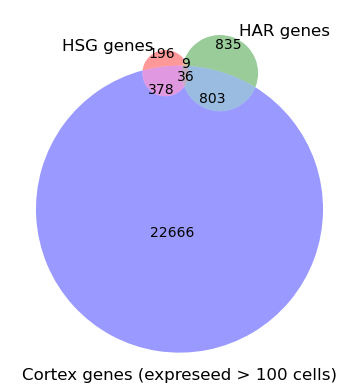

In [50]:
venn3(subsets = (196, 835,9,22666,378,803,36), set_labels = ('HSG genes', 'HAR genes', 'Cortex genes (expreseed > 100 cells)'))

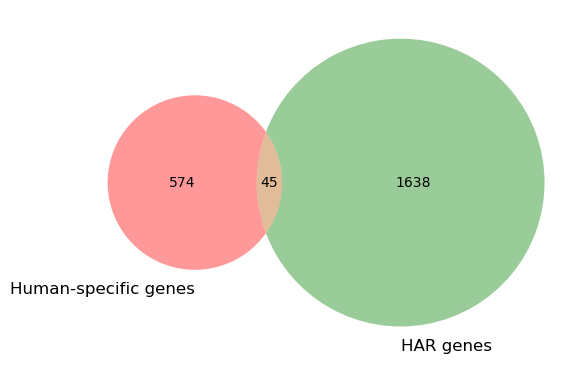

In [54]:
#just har and hsg
from matplotlib_venn import venn2
venn2(subsets = (574,1638,45), set_labels = ('Human-specific genes', 'HAR genes'))

### check duplicated genes 
ther idea here is to check duplicates gene families , because of the close similarities of the family memebrs in the duplicated groups if I see that the duplicated geens do not express in the data but the ancestral is and it is similar so we will put the ancestral for now

In [8]:
hsg_dup2=pd.read_excel("/scratch200/reutj/data/hsg_gene_lists/duplicated_hsg_data.xlsx",sheet_name="SuppTable2")

In [9]:
dup_gene_names=[]
for i in hsg_dup2["Genes"].tolist():
    dup_gene_names.extend(i.split(","))

In [10]:
hsgenes2=["SRGAP2","SRGAP2B","SRGAP2C","HYDIN","HYDIN2","ARHGAP11A","ARHGAP11B","FRMPD2","FRMPD2B"
            ,"SRGAP2D","FAM72A","FAM72B","FAM72C","FAM72D","ROCK1","ROCK1P1","PTPN20","PTPN20CP","GTF2I","GTF2IP1","GTF2IP4"
            ,"GTF2IRD2","GTF2IRD2B","GTF2IRD2P1" ,"NCF1","NCF1C","NCF1B","GPR89A","GPR89B","CD8B","CD8B2"
            ,"NOTCH2","NOTCH2NL","NOTCH2NLB","NOTCH2NLC","NOTCH2NLD","CORO1A","CORO1AP","SLX1A","SLX1B"
            ,"BOLA2B","BOLA2","FCGR1A","FCGR1B","FCGR1CP","ARHGEF34P","ARHGEF35","ARHGEF5","CHRFAM7A","CHRNA7"]

In [11]:
dup_gene_names=list(set(dup_gene_names)|set(hsgenes2))
dup_gene_names.sort()

In [10]:
#go over each duplicate dand see expression in the data-
#if duplicated not in data but ancestral is, remove dup and add ancestral 
dup_gene_names

['ARHGAP11A',
 'ARHGAP11B',
 'ARHGEF34P',
 'ARHGEF35',
 'ARHGEF5',
 'ARHGEF5A',
 'ARHGEF5B',
 'ARHGEF5C',
 'BOLA2',
 'BOLA2A',
 'BOLA2B',
 'CD8B',
 'CD8B-A',
 'CD8B-B',
 'CD8B2',
 'CFC1A',
 'CFC1B',
 'CHRFAM7A',
 'CHRNA7',
 'CORO1A',
 'CORO1AP',
 'DUSP22A',
 'FAM72A',
 'FAM72B',
 'FAM72C',
 'FAM72D',
 'FCGR1A',
 'FCGR1B',
 'FCGR1C',
 'FCGR1CP',
 'FCGR1D',
 'FRMPD2',
 'FRMPD2A',
 'FRMPD2B',
 'GPR89A',
 'GPR89B',
 'GPRIN2A',
 'GPRIN2B',
 'GTF2H2',
 'GTF2H2B',
 'GTF2H2C',
 'GTF2I',
 'GTF2IA',
 'GTF2IB',
 'GTF2IC',
 'GTF2IDR2C',
 'GTF2IP1',
 'GTF2IP4',
 'GTF2IRD2',
 'GTF2IRD2A',
 'GTF2IRD2B',
 'GTF2IRD2P1',
 'HIST2H2BA',
 'HIST2H2BC',
 'HIST2H2BD',
 'HYDIN',
 'HYDIN2',
 'MIR4267A',
 'MIR4267B',
 'MIR4435A',
 'MIR4435B',
 'NAIP',
 'NAIPB',
 'NAIPC',
 'NAIPD',
 'NCF1',
 'NCF1A',
 'NCF1B',
 'NCF1C',
 'NOTCH2',
 'NOTCH2NL',
 'NOTCH2NLB',
 'NOTCH2NLC',
 'NOTCH2NLD',
 'NPY4RA',
 'NPY4RB',
 'OCLN',
 'OCLNB',
 'OR2A-A',
 'OR2A-B',
 'PTPN20',
 'PTPN20A',
 'PTPN20B',
 'PTPN20CP',
 'ROCK1',
 'ROCK1A'

In [90]:
hsg_exp

,Unnamed: 0,gene,ens,Annotated as,num_cells_expressed,mean_expression
0,0,SEPTIN7,ENSG00000122545,protein_coding,263655,3.986133
1,1,AATBC,ENSG00000215458,antisense,302,1.019868
2,2,ABCB10,ENSG00000135776,protein_coding,34502,1.295606
3,3,ABCC12,ENSG00000140798,protein_coding,296,1.074324
4,4,ABCC6,ENSG00000091262,protein_coding,1554,1.072716
...,...,...,...,...,...,...
533,533,LINC02073,ENSG00000267452,lncRNA,2,1.000000
534,534,LINC00868,ENSG00000267535,lncRNA,59,1.101695
535,535,LINC02712,ENSG00000273409,lncRNA,242,1.095041
536,536,AL360294.1/PP2672,ENSG00000279261,lncRNA,0,0.000000


In [12]:
[i for i in dup_gene_names if i in hsg_exp["gene"].to_list()]

['ARHGEF35',
 'BOLA2',
 'CD8B2',
 'CHRFAM7A',
 'FAM72B',
 'FAM72C',
 'FAM72D',
 'FCGR1B',
 'GPR89B',
 'GTF2H2C',
 'GTF2IRD2B',
 'NOTCH2NL',
 'OCLN',
 'SERF1B',
 'SLX1B',
 'SMN2',
 'SRGAP2B',
 'SRGAP2C',
 'TCAF2C']

In [99]:
#arhgef35-good
#bola2-good
#CD8B2- good
#CHRFAM7A- good
#FAM- good
#FCGR1B- good
#GPR89B- good
#GTF2H2C - good
#GTF2IRD2B - good
#NOTCH2NL - good
#OCLN -dont know what its a duplicate of
#SERF1B - dont know what is a duplicate of 
#SLX1B - good
#SRGAP - good
#TCAF2C - good

In [16]:
[i for i in dup_gene_names if i not in hsg_exp["gene"].to_list()]

['ARHGAP11A',
 'ARHGAP11B',
 'ARHGEF34P',
 'ARHGEF5',
 'ARHGEF5A',
 'ARHGEF5B',
 'ARHGEF5C',
 'BOLA2A',
 'BOLA2B',
 'CD8B',
 'CD8B-A',
 'CD8B-B',
 'CFC1A',
 'CFC1B',
 'CHRNA7',
 'CORO1A',
 'CORO1AP',
 'DUSP22A',
 'FAM72A',
 'FCGR1A',
 'FCGR1C',
 'FCGR1CP',
 'FCGR1D',
 'FRMPD2',
 'FRMPD2A',
 'FRMPD2B',
 'GPR89A',
 'GPRIN2A',
 'GPRIN2B',
 'GTF2H2',
 'GTF2H2B',
 'GTF2I',
 'GTF2IA',
 'GTF2IB',
 'GTF2IC',
 'GTF2IDR2C',
 'GTF2IP1',
 'GTF2IP4',
 'GTF2IRD2',
 'GTF2IRD2A',
 'GTF2IRD2P1',
 'HIST2H2BA',
 'HIST2H2BC',
 'HIST2H2BD',
 'HYDIN',
 'HYDIN2',
 'MIR4267A',
 'MIR4267B',
 'MIR4435A',
 'MIR4435B',
 'NAIP',
 'NAIPB',
 'NAIPC',
 'NAIPD',
 'NCF1',
 'NCF1A',
 'NCF1B',
 'NCF1C',
 'NOTCH2',
 'NOTCH2NLB',
 'NOTCH2NLC',
 'NOTCH2NLD',
 'NPY4RA',
 'NPY4RB',
 'OCLNB',
 'OR2A-A',
 'OR2A-B',
 'PTPN20',
 'PTPN20A',
 'PTPN20B',
 'PTPN20CP',
 'ROCK1',
 'ROCK1A',
 'ROCK1B',
 'ROCK1P1',
 'SERF1A',
 'SLX1A',
 'SMN1',
 'SRGAP2',
 'SRGAP2A',
 'SRGAP2D',
 'TCAF1A',
 'TCAF1B',
 'TCAF2A',
 'TCAF2B',
 'TISP43A',
 'T

In [81]:
#check specific genes if expressed
sum(adata.X[:,genes_adata.index("TISP43")].toarray().flatten()>0)
#for example here TISP43 is not expressed

ValueError: 'TISP43' is not in list

In [ ]:
#ADD ARHGAP11A INSTEAD OF ARHGAP11B
#ADD CFC1 INSTEAD OF CFC1B (ANCESTRAL CFC1/CFC1A)..
#ADD CORO1A INSTEAD OF CORO1AP
#ADD DUSP22 INSTEAD OF DUSP22A AND B
#ADD FRMPD2 INSTEAD OF FRMPD2A AND FRMPD2B
#ADD GPRIN2 INSTEAD OF GPRIN2A/B
#ADD GTF2I INSTEAD OF ALL THE PARALOGS
#ADD HIST2H2BF - INSTEAD OF HIST2HB FAMILY
#ADD HYDIN INSTEAD OF HYDIN2
#MIRS NOT IN DATA
#ADD NAIP INSTEAD OF NAIPB/C
#ADD NCF1 INSTEAD OF ITS PARALOGS
#NPYR4 FAMILY NOT EXPRESSED IN DATA
#OR2A1 VERY LOWLY EXPRESSED )31 CELLS( I WILL NOT ADD TO THE DATA
#ADD PTPN20 INSTEAD OF PTPN20B
#ADD ROCK1 INSTEAD OF ITS PARALOGS
#ADD TCAF1 INSTEAD TCAF1A/B
#TISP FAMILY NOT IN DATA

In [21]:
#parlog table for more info
paralogs_genes=pd.read_csv("/scratch200/reutj/data/hsg_with_paralogs.csv")

In [44]:
paralogs_genes.loc[paralogs_genes["query_gene"]=="FRMPD2B",:]

,Unnamed: 0,query_gene,query_ens,query_id,match_gene,match_ens,match_chr,match_start,match_end,identity,match_length,mismatches,gap_openings,e_value,bit_score,query_start,query_end


In [84]:
adata.var

,Chromosome,Accession,Start,End
Gene,,,,
CFAP52,17,ENSG00000166596,9576627,9643459
TP73,1,ENSG00000078900,3652520,3736201
LHX1,17,ENSG00000273706,36936785,36944612
CFAP126,1,ENSG00000188931,161364731,161367874
BHMT,5,ENSG00000145692,79111779,79132290
...,...,...,...,...
ADORA2A-AS1,22,ENSG00000178803,24429206,24495074
ENTPD4,8,ENSG00000197217,23385783,23457695
LINC01833,2,ENSG00000259439,44921077,44939199


In [89]:
hsg

,Unnamed: 0,gene,ens,Annotated as
0,0,SEPTIN7,ENSG00000122545,protein_coding
1,1,AATBC,ENSG00000215458,antisense
2,2,ABCB10,ENSG00000135776,protein_coding
3,3,ABCC12,ENSG00000140798,protein_coding
4,4,ABCC6,ENSG00000091262,protein_coding
...,...,...,...,...
600,77,LINC02073,ENSG00000267452,lncRNA
601,78,LINC00868,ENSG00000267535,lncRNA
602,79,LINC02712,ENSG00000273409,lncRNA
603,80,AL360294.1/PP2672,ENSG00000279261,lncRNA


In [124]:
genes_to_add=["ARHGAP11A","CFC1","CORO1A","DUSP22","FRMPD2","GPRIN2","GTF2I","HIST2H2BF","HYDIN","NAIP","NCF1","PTPN20","ROCK1","TCAF1"]
genes_to_add_df=pd.DataFrame({"gene":adata.var_names[adata.var_names.isin(genes_to_add)],
                             "ens": adata.var.Accession[adata.var_names.isin(genes_to_add)],
                            "Annotated as":"protein_coding"})

In [125]:
hsg=hsg.drop(columns=["Unnamed: 0"])

In [126]:
hsg=pd.concat([hsg,genes_to_add_df],ignore_index=True)

In [127]:
hsg

,gene,ens,Annotated as
0,SEPTIN7,ENSG00000122545,protein_coding
1,AATBC,ENSG00000215458,antisense
2,ABCB10,ENSG00000135776,protein_coding
3,ABCC12,ENSG00000140798,protein_coding
4,ABCC6,ENSG00000091262,protein_coding
...,...,...,...
614,DUSP22,ENSG00000112679,protein_coding
615,GTF2I,ENSG00000263001,protein_coding
616,ARHGAP11A,ENSG00000198826,protein_coding
617,NCF1,ENSG00000158517,protein_coding


In [128]:
hsg.to_csv("/scratch200/reutj/data/hsg_gene_lists/updated_human_specific_genes3.csv")

In [114]:
adata.obs

,Age,Agetext,Ageunit,All_fc_analysis_id,Analysis,CellCycle,CellCycle_G1,CellCycle_G2M,CellCycle_S,Cellconc,...,leiden_scVI,louvain,classes,mark,CellID,CellCycleFraction,Cycling,CellCyclePhase,CellClass,proliferation
CellID,,,,,,,,,,,,,,,,,,,,,
10X298_1:TGTGATGGTCCAGCAC,5.5,5.5w,pcw,4624,Queueing,0.002037,0.000543,0.001358,0.000136,1240,...,9,6,Neuroblast,0,10X298_1:TGTGATGGTCCAGCAC,0.001664,False,Non-cycling,Neuroblast,differentiating
10X298_1:ATGCATGGTTAAAGTG,5.5,5.5w,pcw,4624,Queueing,0.002892,0.001285,0.001526,0.000080,1240,...,9,6,Neuroblast,0,10X298_1:ATGCATGGTTAAAGTG,0.002593,False,Non-cycling,Radial glia,proliferating
10X298_1:TTGGGCGTCACGTAGT,5.5,5.5w,pcw,4624,Queueing,0.002670,0.000191,0.002384,0.000095,1240,...,9,6,Neuroblast,0,10X298_1:TTGGGCGTCACGTAGT,0.002339,False,Non-cycling,Neuroblast,differentiating
10X298_1:TACGCTCTCCCGAGGT,5.5,5.5w,pcw,4624,Queueing,0.003317,0.001167,0.001659,0.000491,1240,...,9,6,Neuroblast,0,10X298_1:TACGCTCTCCCGAGGT,0.003122,False,Non-cycling,Neuroblast,differentiating
10X298_1:TTGCCTGCAAGTTGGG,5.5,5.5w,pcw,4624,Queueing,0.004388,0.000768,0.003510,0.000110,1240,...,9,6,Neuroblast,0,10X298_1:TTGCCTGCAAGTTGGG,0.003877,False,Non-cycling,Neuroblast,differentiating
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X257_2:TAACCAGCAGTAACAA,14.0,14w,pcw,3778,Queueing,0.025884,0.006604,0.010865,0.008415,770,...,3,3,Radial glia,0,10X257_2:TAACCAGCAGTAACAA,0.022677,True,S,Glioblast,proliferating
10X257_1:GGATCTAAGTGGCAGT,14.0,14w,pcw,3612,Queueing,0.040516,0.002734,0.028880,0.008902,770,...,3,3,Radial glia,0,10X257_1:GGATCTAAGTGGCAGT,0.035481,True,S,Radial glia,proliferating
10X257_2:GTCAAACTCCTTGACC,14.0,14w,pcw,3778,Queueing,0.021243,0.007022,0.008866,0.005355,770,...,3,3,Radial glia,0,10X257_2:GTCAAACTCCTTGACC,0.019012,True,S,Glioblast,proliferating
